In [ ]:
# Core libraries
import pandas as pd
import numpy as np
import json

#preprocessing
from sklearn import set_config
set_config(display = 'diagram', transform_output= "pandas")

# Model selection
from sklearn.metrics import root_mean_squared_log_error, root_mean_squared_error
from sklearn.model_selection import cross_val_score,cross_validate, TimeSeriesSplit
import optuna, optuna_dashboard

# import for linear model
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import make_column_transformer

#feature selection
from sklearn.inspection import permutation_importance

# models
from sklearn.linear_model import ElasticNet #always like to have a linear model for comparison
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns


# Project config
from src.params import *
from src.utils import *
from src.models.baseline import *
from src.preprocess.cleaning import *
from src.preprocess.features import *
from src.preprocess.pipeline import *

# Plot configuration
%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
import warnings
warnings.filterwarnings("ignore")
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
df_custom = pd.read_csv("../data/processed/df_processed.csv")
df_14 = pd.read_csv("../data/processed/df_processed_all_lag_14.csv")
df_21 = pd.read_csv("../data/processed/df_processed_all_lag_21.csv")

# I. Baseline

There are several baselines we can use to check our models against. 
1. persistence baseline: y_pred = y_today
2. linear extrapolation: y_pred = y_today + (y_today - y_yesterday)
3. last 3 days average: y_pred 

In order to perform a fair comparison with the models, the baseline score must be calculated using the timeseries splits used for model crossvalidation. 

## I.1 Baseline comparison

In [13]:
#creation time serie split
# val set size: 30 days per city (180 because 6 cities)
# gap between train and val set to avoid trailinf effects: 7 days (42 in total)
tscv = TimeSeriesSplit(n_splits= 5, gap= 42, test_size= 180) # val set of 1month per city #one week gap

### I.1.1 On "custom" dataset

In [14]:
df_custom = df_custom.sort_values(by="date", ascending= True)
y = df_custom.target
X = df_custom.drop(columns= ["target"])

In [15]:
baseline_custom = baseline_crossval(X, y, tscv= tscv)
baseline_custom.columns = ["RMSE_baseline_custom"]
baseline_custom

✅ Baseline calculated and averaged over all folds


,RMSE_baseline_custom
persistence_baseline,0.647663
Extrapolation_baseline,1.041081
Average_baseline,0.639346


### I.1.2 On all_lags_14

In [16]:
df_14 = df_14.sort_values(by="date", ascending= True)
y_14 = df_14.target
X_14 = df_14.drop(columns= ["target"])

In [17]:
baseline_14 = baseline_crossval(X_14, y_14, tscv= tscv)
baseline_14.columns = ["RMSE_baseline_14"]
baseline_14

✅ Baseline calculated and averaged over all folds


,RMSE_baseline_14
persistence_baseline,0.658003
Extrapolation_baseline,1.033128
Average_baseline,0.647449


### I.1.3 On all_lags_21


In [18]:
df_21 = df_21.sort_values(by="date", ascending= True)
y_21 = df_21.target
X_21 = df_21.drop(columns= ["target"])

baseline_21 = baseline_crossval(X_21, y_21, tscv= tscv)
baseline_21.columns = ["RMSE_baseline_21"]
baseline_21

✅ Baseline calculated and averaged over all folds


,RMSE_baseline_21
persistence_baseline,0.665740
Extrapolation_baseline,1.066277
Average_baseline,0.649488


The persistence baseline is one of the two best across all feature engineering approach and is easier to compute so we'll use this one as benchmark. 

## I.2 Baseline visualization

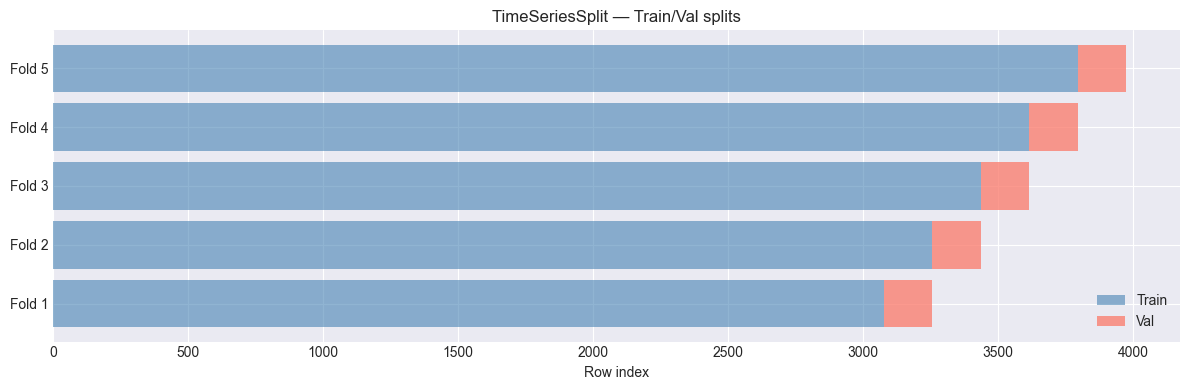

In [19]:
# ── 1. VISUALISATION DES FOLDS (CLAUDE)────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))

for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
    ax.barh(fold, len(train_idx), left=0, color="steelblue", alpha=0.6, label="Train" if fold == 0 else "")
    ax.barh(fold, len(val_idx), left=train_idx[-1], color="salmon", alpha=0.8, label="Val" if fold == 0 else "")

ax.set_yticks(range(5))
ax.set_yticklabels([f"Fold {i+1}" for i in range(5)])
ax.set_xlabel("Row index")
ax.set_title("TimeSeriesSplit — Train/Val splits")
ax.legend()
plt.tight_layout()

## I.3 Baseline final score on full train set

In [20]:
baseline_full_custom = baseline_calculation(X= X, y= y, baseline= "persistence")
baseline_full_custom


0.5673330155384547

In [21]:
baseline_full_14 = baseline_calculation(X= X_14, y= y_14, baseline= "persistence")
baseline_full_14

0.5402023661286455

In [22]:
baseline_full_21 = baseline_calculation(X= X_21, y= y_21, baseline= "persistence")
baseline_full_21

0.5482516314676399

# II. model selection

We'll compare the score of different models and check their score. 
here, the model will generate y_pred as a log, so w'ell directly compare y_true and y_pred with RMSE instead of RMSLE. 

## II.1 With One Hot Encoding of cities

Using one hot encoder because couldnt handle category in the loop with sklearn crossval for some reason

In [23]:
encoder  = make_column_transformer((OneHotEncoder(sparse_output= False, handle_unknown= "ignore"),
                                   ["city"]),
                                   remainder= "passthrough",
                                   verbose_feature_names_out= False)



estimators = {
    "elastic": make_pipeline(encoder,
                            StandardScaler(),
                            ElasticNet()),
    "xgboost": make_pipeline(encoder, XGBRegressor()),
    "lgbm": make_pipeline(encoder,LGBMRegressor()),
    "catboost": make_pipeline(encoder, CatBoostRegressor())
}


### II.1.1 crossvall with custom feature engineering dataset

In [24]:
X = X.sort_values(by= "date", ascending= True)
X = X.drop(columns="date")

In [25]:
model_scores = []
for model_name, model in estimators.items():
    results = cross_validate(
        model, X, y,
        cv=tscv,
        scoring="neg_root_mean_squared_error",
        return_train_score=False
    )
    model_scores.append({
        "name": model_name,
        "mean_score": -results["test_score"].mean(),
        "std_score": results["test_score"].std(),
        "mean_fit_time": results["fit_time"].mean()
    })

ohe_custom_crossval = pd.DataFrame(model_scores).set_index("name")
ohe_custom_crossval


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000279 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2713
[LightGBM] [Info] Number of data points in the train set: 3077, number of used features: 24
[LightGBM] [Info] Start training from score 2.232122
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000301 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2721
[LightGBM] [Info] Number of data points in the train set: 3257, number of used features: 24
[LightGBM] [Info] Start training from score 2.237293
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of test

,mean_score,std_score,mean_fit_time
name,,,
elastic,0.600418,0.100611,0.003193
xgboost,0.565792,0.077435,0.214930
lgbm,0.537492,0.079229,0.525268
catboost,0.548072,0.083197,0.622948


### II.1.2 crossvall with all_lags_14 features

In [26]:
X_14 = X_14.sort_values(by= "date", ascending= True)
X_14 = X_14.drop(columns="date")

model_scores = []
for model_name, model in estimators.items():
    results = cross_validate(
        model, X_14, y_14,
        cv=tscv,
        scoring="neg_root_mean_squared_error",
        return_train_score=False
    )
    model_scores.append({
        "name": model_name,
        "mean_score": -results["test_score"].mean(),
        "std_score": results["test_score"].std(),
        "mean_fit_time": results["fit_time"].mean()
    })

ohe_14_crossval = pd.DataFrame(model_scores).set_index("name")
ohe_14_crossval


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000334 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4750
[LightGBM] [Info] Number of data points in the train set: 3037, number of used features: 32
[LightGBM] [Info] Start training from score 2.233692
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000371 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4758
[LightGBM] [Info] Number of data points in the train set: 3217, number of used features: 32
[LightGBM] [Info] Start training from score 2.240123
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of test

,mean_score,std_score,mean_fit_time
name,,,
elastic,0.600436,0.098829,0.003128
xgboost,0.581029,0.066372,0.213599
lgbm,0.540984,0.065135,0.531352
catboost,0.544391,0.062716,0.682016


### II.1.3 crossval with all_lags_21 features

In [27]:
X_21 = X_21.sort_values(by= "date", ascending= True)
X_21 = X_21.drop(columns="date")

model_scores = []
for model_name, model in estimators.items():
    results = cross_validate(
        model, X_21, y_21,
        cv=tscv,
        scoring="neg_root_mean_squared_error",
        return_train_score=False
    )
    model_scores.append({
        "name": model_name,
        "mean_score": -results["test_score"].mean(),
        "std_score": results["test_score"].std(),
        "mean_fit_time": results["fit_time"].mean()
    })

ohe_21_crossval = pd.DataFrame(model_scores).set_index("name")
ohe_21_crossval

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000374 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6526
[LightGBM] [Info] Number of data points in the train set: 2883, number of used features: 39
[LightGBM] [Info] Start training from score 2.236153
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000408 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6533
[LightGBM] [Info] Number of data points in the train set: 3063, number of used features: 39
[LightGBM] [Info] Start training from score 2.241162
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of test

,mean_score,std_score,mean_fit_time
name,,,
elastic,0.594542,0.095834,0.006080
xgboost,0.587932,0.061249,0.230517
lgbm,0.561729,0.068017,0.549252
catboost,0.549475,0.065501,0.858387


## II.2 with native handling of categories

Objective: try them with native handling of the city category

we'll need to do the crossval loop by hand using the timeseries split from before

### II.2.1 For custom feature engineering

In [28]:
import time
X["city"] = X["city"].astype("category")
models = {"xgboost": lambda: XGBRegressor(enable_categorical= True),
          "lgbm": lambda: LGBMRegressor(),
          "catboost": lambda: CatBoostRegressor(verbose= 0, cat_features= ["city"])
}

model_perf = []

for model_name, model_instance in models.items():

    print(f"testing model {model_name}")
    fold_score = []
    fold_time = []


    for train_idx, val_idx in tscv.split(X):
        X_fold_train, y_fold_train = X.iloc[train_idx], y.iloc[train_idx]
        X_fold_val, y_fold_val = X.iloc[val_idx], y.iloc[val_idx]

        model = model_instance()
        t0 = time.time()
        model.fit(X_fold_train, y_fold_train)
        fold_time.append(time.time() - t0)

        y_fold_pred = model.predict(X_fold_val)
        fold_score.append(root_mean_squared_error(y_fold_val, y_fold_pred))

    model_results = {
        "name": model_name,
        "score": np.mean(fold_score),
        "fit_time": np.mean(fold_time),
        "stability": np.std(fold_score)
    }
    model_perf.append(model_results)

cat_custom_crossval = pd.DataFrame(model_perf).set_index("name")
cat_custom_crossval

testing model xgboost
testing model lgbm
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000267 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2708
[LightGBM] [Info] Number of data points in the train set: 3077, number of used features: 19
[LightGBM] [Info] Start training from score 2.232122
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000255 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2716
[LightGBM] [Info] Number of data points in the train set: 3257, number of used features: 19
[LightGBM] [Info] Start training from score 2.237293
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000292 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2728
[LightGBM] [Info] Number of data points in the train set: 3437, number of used fe

,score,fit_time,stability
name,,,
xgboost,0.568443,0.213187,0.074816
lgbm,0.538602,0.538334,0.084522
catboost,0.544855,1.021095,0.083937


### II.2.2 For all_lags_14 

In [29]:

X_14["city"] = X_14["city"].astype("category")
models = {"xgboost": lambda: XGBRegressor(enable_categorical= True),
          "lgbm": lambda: LGBMRegressor(),
          "catboost": lambda: CatBoostRegressor(verbose= 0, cat_features= ["city"])
}

model_perf = []

for model_name, model_instance in models.items():

    print(f"testing model {model_name}")
    fold_score = []
    fold_time = []


    for train_idx, val_idx in tscv.split(X_14):
        X_fold_train, y_fold_train = X_14.iloc[train_idx], y_14.iloc[train_idx]
        X_fold_val, y_fold_val = X_14.iloc[val_idx], y_14.iloc[val_idx]

        model = model_instance()
        t0 = time.time()
        model.fit(X_fold_train, y_fold_train)
        fold_time.append(time.time() - t0)

        y_fold_pred = model.predict(X_fold_val)
        fold_score.append(root_mean_squared_error(y_fold_val, y_fold_pred))

    model_results = {
        "name": model_name,
        "score": np.mean(fold_score),
        "fit_time": np.mean(fold_time),
        "stability": np.std(fold_score)
    }
    model_perf.append(model_results)

cat_14_crossval = pd.DataFrame(model_perf).set_index("name")
cat_14_crossval

testing model xgboost
testing model lgbm
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000323 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4745
[LightGBM] [Info] Number of data points in the train set: 3037, number of used features: 27
[LightGBM] [Info] Start training from score 2.233692
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000350 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4753
[LightGBM] [Info] Number of data points in the train set: 3217, number of used features: 27
[LightGBM] [Info] Start training from score 2.240123
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000303 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4762
[LightGBM] [Info] Number of data points in the train set: 3397, number of used fe

,score,fit_time,stability
name,,,
xgboost,0.572188,0.224294,0.064334
lgbm,0.541351,0.535096,0.063572
catboost,0.546679,1.054988,0.064619


### II.2.3 Foll all_lags_21

In [30]:
X_21["city"] = X_21["city"].astype("category")
models = {"xgboost": lambda: XGBRegressor(enable_categorical= True),
          "lgbm": lambda: LGBMRegressor(),
          "catboost": lambda: CatBoostRegressor(verbose= 0, cat_features= ["city"])
}

model_perf = []

for model_name, model_instance in models.items():

    print(f"testing model {model_name}")
    fold_score = []
    fold_time = []


    for train_idx, val_idx in tscv.split(X_21):
        X_fold_train, y_fold_train = X_21.iloc[train_idx], y_21.iloc[train_idx]
        X_fold_val, y_fold_val = X_21.iloc[val_idx], y_21.iloc[val_idx]

        model = model_instance()
        t0 = time.time()
        model.fit(X_fold_train, y_fold_train)
        fold_time.append(time.time() - t0)

        y_fold_pred = model.predict(X_fold_val)
        fold_score.append(root_mean_squared_error(y_fold_val, y_fold_pred))

    model_results = {
        "name": model_name,
        "score": np.mean(fold_score),
        "fit_time": np.mean(fold_time),
        "stability": np.std(fold_score)
    }
    model_perf.append(model_results)

cat_21_crossval = pd.DataFrame(model_perf).set_index("name")
cat_21_crossval

testing model xgboost
testing model lgbm
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000346 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6521
[LightGBM] [Info] Number of data points in the train set: 2883, number of used features: 34
[LightGBM] [Info] Start training from score 2.236153
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000349 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6528
[LightGBM] [Info] Number of data points in the train set: 3063, number of used features: 34
[LightGBM] [Info] Start training from score 2.241162
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000400 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6542
[LightGBM] [Info] Number of data points in the train set: 3243, number of used fe

,score,fit_time,stability
name,,,
xgboost,0.598402,0.222464,0.051813
lgbm,0.557432,0.537944,0.067680
catboost,0.553695,1.170556,0.066196


Conclusion:
comparison of scores and fit time across type of features, type of model pipeline (encoding or not) and type of models shows that
- xgboost worse than lightgbm and catboost. 
- catboost performs well but much slower
- native handling of category doesnt brings improvement

Decision:
We'll use lightgbm with one hot encoding of cities moving forward. The custom feature engineering works so we'll keep that

# III. Feature selection

In [ ]:
df_custom = df_custom.sort_values(by="date", ascending= True)
y = df_custom.target
X = df_custom.drop(columns= ["target", "date"])
tscv = TimeSeriesSplit(n_splits= 5, gap= 42, test_size= 180)


In [56]:
encoder  = make_column_transformer((OneHotEncoder(sparse_output= False, handle_unknown= "ignore"),
                                   ["city"]),
                                   remainder= "passthrough",
                                   verbose_feature_names_out= False)

pipe = make_pipeline(encoder,LGBMRegressor(verbose = -1))
pipe


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('lgbmregressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('onehotencoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different

In [66]:
def get_feature_importance(pipe, X, y, n_repeats= 400):

    pipe.fit(X,y)
    #permutation
    print(f"⚙️ testing permutation...")

    perm = permutation_importance(pipe, X, y,
                                  n_repeats= n_repeats,
                                  n_jobs= -1,
                                  random_state= 273,
                                  scoring= "neg_root_mean_squared_error")
    #metrics
    df = pd.DataFrame({"feature": X.columns,
                       "importance_mean": perm.importances_mean,
                       "importance_std": perm.importances_std})
    df = df.sort_values(by="importance_mean", ascending= False)

    return df

In [67]:
permutation = get_feature_importance(pipe= pipe, X= X, y= y,n_repeats= 100)
permutation

⚙️ testing permutation...


,feature,importance_mean,importance_std
15,lag_1,0.272706,0.003563
0,city,0.039057,0.001271
5,precipitation,0.035121,0.001442
2,temp_max,0.033346,0.001057
13,lag_avg_14,0.033242,0.000950
7,wind_speed,0.032987,0.001165
6,pressure,0.032146,0.001129
8,wind_direction,0.032117,0.001056
17,lag_3,0.025968,0.000665
4,humidity,0.022766,0.000783


In [ ]:
features_ranked = permutation["feature"].tolist()
top_results = []
for k in range(1,len(features_ranked)):
    top_k_features = features_ranked[:k+1]
    print(top_k_features)
    X_top = X[top_k_features]

    results = cross_validate(estimator= pipe, X= X_top, y= y, cv= tscv, n_jobs= -1, scoring= "neg_root_mean_squared_error")
    result_dict= {f"nb_features": k,
     "score": -results["test_score"].mean(),
     "std_score": results["test_score"].std()}
    top_results.append(result_dict)

top_k_df = pd.DataFrame(top_results)
top_k_df


['lag_1', 'city']
['lag_1', 'city', 'precipitation']
['lag_1', 'city', 'precipitation', 'temp_max']
['lag_1', 'city', 'precipitation', 'temp_max', 'lag_avg_14']
['lag_1', 'city', 'precipitation', 'temp_max', 'lag_avg_14', 'wind_speed']
['lag_1', 'city', 'precipitation', 'temp_max', 'lag_avg_14', 'wind_speed', 'pressure']
['lag_1', 'city', 'precipitation', 'temp_max', 'lag_avg_14', 'wind_speed', 'pressure', 'wind_direction']
['lag_1', 'city', 'precipitation', 'temp_max', 'lag_avg_14', 'wind_speed', 'pressure', 'wind_direction', 'lag_3']
['lag_1', 'city', 'precipitation', 'temp_max', 'lag_avg_14', 'wind_speed', 'pressure', 'wind_direction', 'lag_3', 'humidity']
['lag_1', 'city', 'precipitation', 'temp_max', 'lag_avg_14', 'wind_speed', 'pressure', 'wind_direction', 'lag_3', 'humidity', 'week_std']
['lag_1', 'city', 'precipitation', 'temp_max', 'lag_avg_14', 'wind_speed', 'pressure', 'wind_direction', 'lag_3', 'humidity', 'week_std', 'lag_2']
['lag_1', 'city', 'precipitation', 'temp_max', 

,nb_features,score,std_score
0,1,0.421121,0.030122
1,2,0.409603,0.026292
2,3,0.397373,0.030199
3,4,0.396726,0.023651
4,5,0.392079,0.026197
5,6,0.385259,0.028349
6,7,0.385524,0.025321
7,8,0.382068,0.029081
8,9,0.380755,0.028308
9,10,0.384305,0.026677


# IV. Model tuning 

In [74]:
pipe.get_params()

{'memory': None,
 'steps': [('columntransformer',
   ColumnTransformer(remainder='passthrough',
                     transformers=[('onehotencoder',
                                    OneHotEncoder(handle_unknown='ignore',
                                                  sparse_output=False),
                                    ['city'])],
                     verbose_feature_names_out=False)),
  ('lgbmregressor', LGBMRegressor(verbose=-1))],
 'transform_input': None,
 'verbose': False,
 'columntransformer': ColumnTransformer(remainder='passthrough',
                   transformers=[('onehotencoder',
                                  OneHotEncoder(handle_unknown='ignore',
                                                sparse_output=False),
                                  ['city'])],
                   verbose_feature_names_out=False),
 'lgbmregressor': LGBMRegressor(verbose=-1),
 'columntransformer__force_int_remainder_cols': 'deprecated',
 'columntransformer__n_jobs': None,
 'col

In [105]:
X["city"] = X["city"].astype("category")
selected_features = features_ranked[:10]
X_selected = X[selected_features]


In [ ]:
def objective(trial):

    params = {
    "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
    "n_estimators":      trial.suggest_int("n_estimators", 100, 1000),
    "num_leaves":        trial.suggest_int("num_leaves", 20, 200),
    "max_depth":         trial.suggest_int("max_depth", 3, 12),
    "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
    "reg_alpha":         trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
    "reg_lambda":        trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
    "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
    "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
    "subsample_freq":    1,
    "n_jobs":            1,
    "random_state":      273,
    "verbose":           -1,
}
    encoder  = make_column_transformer((OneHotEncoder(sparse_output= False, handle_unknown= "ignore"),
                                   ["city"]),
                                   remainder= "passthrough",
                                   verbose_feature_names_out= False)
    pipe = make_pipeline(encoder, LGBMRegressor(**params))


    scores = cross_val_score(pipe, X_selected, y, cv= tscv, scoring= "neg_root_mean_squared_error", n_jobs= -1)
    mean_score = - scores.mean()
    std_score = scores.std()



    return mean_score


In [ ]:


study = optuna.create_study(
    direction = "minimize",
    sampler= optuna.samplers.TPESampler(seed= 273),
)

study.optimize(objective, n_trials= 1000, show_progress_bar= True)

print(f"Best score : {study.best_value:.4f}")
print(f"Best params: {study.best_params}")


[I 2026-03-01 15:29:14,431] A new study created in memory with name: no-name-30456d06-17ac-4815-8c5b-e831e4c3f5c9


  0%|          | 0/1000 [00:00<?, ?it/s]

[I 2026-03-01 15:29:14,526] Trial 0 finished with value: 0.40757095546283206 and parameters: {'learning_rate': 0.012806454641993209, 'n_estimators': 158, 'num_leaves': 31, 'max_depth': 3, 'min_child_samples': 56, 'reg_alpha': 1.7954025154797888, 'reg_lambda': 0.08741958478198075, 'subsample': 0.8471694412344531, 'colsample_bytree': 0.9775985921666301}. Best is trial 0 with value: 0.40757095546283206.
[I 2026-03-01 15:29:14,584] Trial 1 finished with value: 0.3779968644291093 and parameters: {'learning_rate': 0.047131342668810416, 'n_estimators': 126, 'num_leaves': 111, 'max_depth': 4, 'min_child_samples': 52, 'reg_alpha': 0.0001469788653862949, 'reg_lambda': 1.0233996246412128e-06, 'subsample': 0.8718143764822617, 'colsample_bytree': 0.9700574065227887}. Best is trial 1 with value: 0.3779968644291093.
[I 2026-03-01 15:29:14,658] Trial 2 finished with value: 0.378734282708347 and parameters: {'learning_rate': 0.15609373778396965, 'n_estimators': 373, 'num_leaves': 191, 'max_depth': 3, '

In [113]:
optuna.visualization.plot_optimization_history(study)


In [114]:
optuna.visualization.plot_param_importances(study)


In [115]:
optuna.visualization.plot_parallel_coordinate(study)

In [121]:
import json

best_params = {**study.best_params, "subsample_freq": 1, "random_state": 273, "verbose": -1}

with open("best_params.json", "w") as f:
    json.dump(best_params, f, indent=2)